## SECTION 1: Imports & Configuration

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random
from pathlib import Path
from sklearn.model_selection import train_test_split
from tqdm import tqdm

In [5]:
# Define paths
# Note: Update the DATA_ROOT path to point to the local copy of the LFW dataset
# and the prepocessed images will be saved in the OUTPUT_DIR
DATA_ROOT = Path(r"raw_data/lfw-deepfunneled/lfw-deepfunneled")
OUTPUT_DIR = Path("processed_data")
OUTPUT_DIR.mkdir(exist_ok=True)

In [6]:
# minimum images per person (justified in the report)
MIN_IMAGES   = 3          # satisfies both contrastive and triplet loss requirements
MAX_IMAGES   = 50         # cap to prevent class dominance, can be 30
IMG_SIZE     = (105, 105) # resize target (H, W)
TEST_SPLIT   = 0.2        # 20% of persons go to test set
RANDOM_SEED  = 42

TRAIN_SPLIT = 0.70        # 70% of eligible persons → training
VAL_SPLIT   = 0.15        # 15% of eligible persons → validation (threshold tuning)
TEST_SPLIT  = 0.15        # 15% of eligible persons → final evaluation (10-model comparison)
RANDOM_SEED = 42

PAIRS_PER_PERSON    = 5   # positive pairs to generate per person
TRIPLETS_PER_PERSON = 5   # triplets to generate per person

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

## SECTION 2: Raw Data Exploration

In [9]:
# Dataset statistics
person_image_counts = {}

for person_folder in DATA_ROOT.iterdir():
    if person_folder.is_dir():
        images = list(person_folder.glob("*.jpg"))
        person_image_counts[person_folder.name] = len(images)

total_persons = len(person_image_counts)
total_images  = sum(person_image_counts.values())
counts        = list(person_image_counts.values())

print(f"  Total persons : {total_persons:,}")
print(f"  Total images  : {total_images:,}")
print(f"  Min images    : {min(counts)}")
print(f"  Max images    : {max(counts)}")
print(f"  Mean images   : {np.mean(counts):.2f}")
print(f"  Median images : {np.median(counts):.2f}")

# count how many people have only 1 image (useless for training)
only_one = sum(1 for c in counts if c == 1)
print(f"\n  People with only 1 image : {only_one:,} "
      f"({100*only_one/total_persons:.1f}% of dataset)")
print(f" These are USELESS for training — cannot form any pair or triplet")

  Total persons : 5,749
  Total images  : 13,233
  Min images    : 1
  Max images    : 530
  Mean images   : 2.30
  Median images : 1.00

  People with only 1 image : 4,069 (70.8% of dataset)
 These are USELESS for training — cannot form any pair or triplet


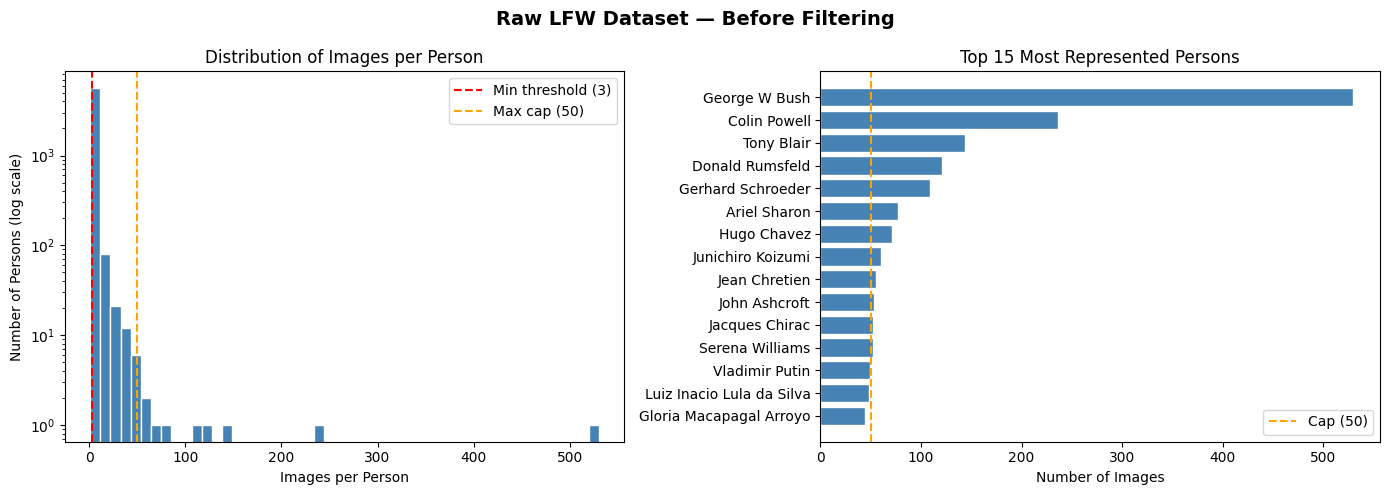

 Plot saved to processed_data/01_raw_distribution.png


In [10]:
# Visualize raw distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Raw LFW Dataset — Before Filtering", fontsize=14, fontweight='bold')

# Left: full histogram (log scale to handle skew)
axes[0].hist(counts, bins=50, color='steelblue', edgecolor='white')
axes[0].set_yscale('log')
axes[0].set_xlabel("Images per Person")
axes[0].set_ylabel("Number of Persons (log scale)")
axes[0].set_title("Distribution of Images per Person")
axes[0].axvline(MIN_IMAGES, color='red',    linestyle='--', label=f'Min threshold ({MIN_IMAGES})')
axes[0].axvline(MAX_IMAGES, color='orange', linestyle='--', label=f'Max cap ({MAX_IMAGES})')
axes[0].legend()

# Right: top 15 most represented persons
top15 = sorted(person_image_counts.items(), key=lambda x: x[1], reverse=True)[:15]
names, img_counts = zip(*top15)
short_names = [n.replace('_', ' ') for n in names]

axes[1].barh(short_names[::-1], img_counts[::-1], color='steelblue', edgecolor='white')
axes[1].set_xlabel("Number of Images")
axes[1].set_title("Top 15 Most Represented Persons")
axes[1].axvline(MAX_IMAGES, color='orange', linestyle='--', label=f'Cap ({MAX_IMAGES})')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_raw_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Plot saved to processed_data/01_raw_distribution.png")

In [11]:
# Filtering impact analysis
# Show how many persons survive at different thresholds
# This JUSTIFIES my choice of MIN_IMAGES = 3

thresholds = [1, 2, 3, 4, 5, 10]
print("\n Filtering Impact Analysis:")
print(f" {'Min Threshold':<18} {'Eligible Persons':<20} {'% Retained'}")
for t in thresholds:
    eligible = sum(1 for c in counts if c >= t)
    pct = 100 * eligible / total_persons
    marker = " our choice" if t == MIN_IMAGES else ""
    print(f"  {t:<18} {eligible:<20,} {pct:.1f}%{marker}")



 Filtering Impact Analysis:
 Min Threshold      Eligible Persons     % Retained
  1                  5,749                100.0%
  2                  1,680                29.2%
  3                  901                  15.7% our choice
  4                  610                  10.6%
  5                  423                  7.4%
  10                 158                  2.7%


## SECTION 3: Filtering & Person-Level Split


In [19]:
# Apply min/max filter to get the final list of eligible persons for training
eligible_persons = {
    person: count 
    for person, count in person_image_counts.items()
    if MIN_IMAGES <= count <= (MAX_IMAGES)
}

filtered_counts = list(eligible_persons.values())
filtered_names  = list(eligible_persons.keys())
print("\n After applying min/max filter:")
print(f"  Eligible persons : {len(eligible_persons):,}")
print(f"  Total images     : {sum(filtered_counts):,}")
print(f"  Min images       : {min(filtered_counts)}")
print(f"  Max images       : {max(filtered_counts)}")
print(f"  Mean images      : {np.mean(filtered_counts):.2f}")
print(f"  Median images    : {np.median(filtered_counts):.2f}")


 After applying min/max filter:
  Eligible persons : 889
  Total images     : 6,046
  Min images       : 3
  Max images       : 49
  Mean images      : 6.80
  Median images    : 4.00


In [20]:
# Split persons NOT images — this is the open-set protocol
# Persons in test are completely unseen during training

train_persons, temp_persons = train_test_split(
    filtered_names,
    test_size=(VAL_SPLIT + TEST_SPLIT),
    random_state=RANDOM_SEED
)

val_persons, test_persons = train_test_split(
    temp_persons,
    test_size=TEST_SPLIT / (VAL_SPLIT + TEST_SPLIT),
    random_state=RANDOM_SEED
)

# Display split statistics
print(f"  Train persons : {len(train_persons):,} ({100*len(train_persons)/len(filtered_names):.1f}%)")
print(f"  Val persons   : {len(val_persons):,}  ({100*len(val_persons)/len(filtered_names):.1f}%)")
print(f"  Test persons  : {len(test_persons):,}  ({100*len(test_persons)/len(filtered_names):.1f}%)")

# Sanity check — confirm zero overlap
assert len(set(train_persons) & set(val_persons))  == 0, "Overlap between train and val"
assert len(set(train_persons) & set(test_persons)) == 0, "Overlap between train and test"
assert len(set(val_persons)   & set(test_persons)) == 0, "Overlap between val and test"

  Train persons : 622 (70.0%)
  Val persons   : 133  (15.0%)
  Test persons  : 134  (15.1%)


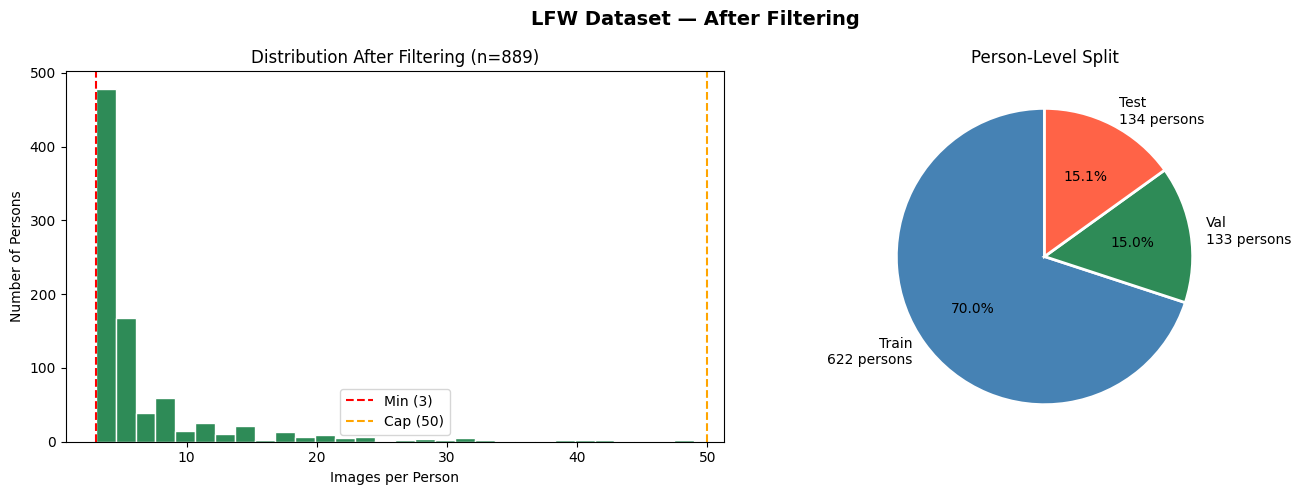

 Plot saved to processed_data/02_filtered_distribution.png


In [21]:
# Visualize filtered distribution and split breakdown
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("LFW Dataset — After Filtering", fontsize=14, fontweight='bold')

# Left: filtered histogram
axes[0].hist(filtered_counts, bins=30, color='seagreen', edgecolor='white')
axes[0].set_xlabel("Images per Person")
axes[0].set_ylabel("Number of Persons")
axes[0].set_title(f"Distribution After Filtering (n={len(eligible_persons):,})")
axes[0].axvline(MIN_IMAGES, color='red',    linestyle='--', label=f'Min ({MIN_IMAGES})')
axes[0].axvline(MAX_IMAGES, color='orange', linestyle='--', label=f'Cap ({MAX_IMAGES})')
axes[0].legend()

# Right: split breakdown pie chart
split_labels = [
    f'Train\n{len(train_persons)} persons',
    f'Val\n{len(val_persons)} persons',
    f'Test\n{len(test_persons)} persons'
]
split_sizes  = [len(train_persons), len(val_persons), len(test_persons)]
colors       = ['steelblue', 'seagreen', 'tomato']

axes[1].pie(split_sizes, labels=split_labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title("Person-Level Split")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_filtered_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Plot saved to processed_data/02_filtered_distribution.png")

## SECTION 4: Image Preprocessing & Augmentation

In [22]:
# Image preprocessing function
def preprocess_image(img_path):
    # Load, resize, and normalize a single image.
    # Returns float32 array of shape (224, 224, 3) in range [0, 1]
    # why? - resizing to a common size is needed for batch processing and model input
    # normalization to [0, 1] is common for neural network inputs to improve training stability
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # OpenCV loads BGR by default
    img = cv2.resize(img, IMG_SIZE)
    img = img.astype(np.float32) / 255.0        # normalize to [0, 1]
    return img


# Offline augmentation functions
def augment_image(img):
    # Apply a random combination of augmentations to a single image.
    # All augmentations are label-preserving for face verification.
    img = img.copy()

    # Horizontal flip (50% chance)
    if random.random() > 0.5:
        img = np.fliplr(img)

    # Small rotation ±15 degrees
    if random.random() > 0.5:
        angle = random.uniform(-15, 15)
        h, w  = img.shape[:2]
        M     = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
        img   = cv2.warpAffine(img, M, (w, h))

    # Brightness adjustment
    if random.random() > 0.5:
        factor = random.uniform(0.7, 1.3)
        img    = np.clip(img * factor, 0, 1)

    # Contrast adjustment
    if random.random() > 0.5:
        mean   = img.mean()
        factor = random.uniform(0.8, 1.2)
        img    = np.clip((img - mean) * factor + mean, 0, 1)

    # Saturation adjustment
    if random.random() > 0.5:
        img_uint8 = (img * 255).astype(np.uint8)
        img_hsv = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2HSV).astype(np.float32)
        img_hsv[:,:,1] = np.clip(img_hsv[:,:,1] * random.uniform(0.7, 1.3), 0, 255)
        img_uint8 = cv2.cvtColor(img_hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)
        img = img_uint8.astype(np.float32) / 255.0

    # Mild Gaussian blur
    if random.random() > 0.7:    # less frequent than others
        img_uint8 = (img * 255).astype(np.uint8)
        img_uint8 = cv2.GaussianBlur(img_uint8, (3, 3), 0)
        img       = img_uint8.astype(np.float32) / 255.0

    # AWGN — subtle noise
    if random.random() > 0.7:    # less frequent than others
        noise = np.random.normal(0, 0.02, img.shape).astype(np.float32)
        img   = np.clip(img + noise, 0, 1)

    return img

In [23]:
# Load and augment all persons
# Training persons: load + augment up to MAX_IMAGES
# Val/Test persons: load only, no augmentation

def load_person_images(person_name, augment=False):
    person_path = DATA_ROOT / person_name
    img_paths = list(person_path.glob("*.jpg"))
    images = [preprocess_image(p) for p in img_paths]

    if augment and len(images) < MAX_IMAGES:
        original_images = images.copy()
        attempts = 0
        max_attempts = MAX_IMAGES * 3  # safety limit

        while len(images) < MAX_IMAGES and attempts < max_attempts:
            base_img = random.choice(original_images)
            aug_img  = augment_image(base_img)
            images.append(aug_img)
            attempts += 1

    return images

In [24]:
# building image bank for all splits
# image_bank = { person_name: [img1, img2, ...] }

train_bank = {}
for person in tqdm(train_persons):
    train_bank[person] = load_person_images(person, augment=True)

val_bank = {}
for person in tqdm(val_persons):
    val_bank[person] = load_person_images(person, augment=False)

test_bank = {}
for person in tqdm(test_persons):
    test_bank[person] = load_person_images(person, augment=False)

train_total = sum(len(v) for v in train_bank.values())
val_total   = sum(len(v) for v in val_bank.values())
test_total  = sum(len(v) for v in test_bank.values())

print(f"  Train images : {train_total:,} (was {sum(eligible_persons[p] for p in train_persons):,} before augmentation)")
print(f"  Val images   : {val_total:,}")
print(f"  Test images  : {test_total:,}")

100%|██████████| 134/134 [00:10<00:00, 12.50it/s]

  Train images : 31,100 (was 4,263 before augmentation)
  Val images   : 876
  Test images  : 907


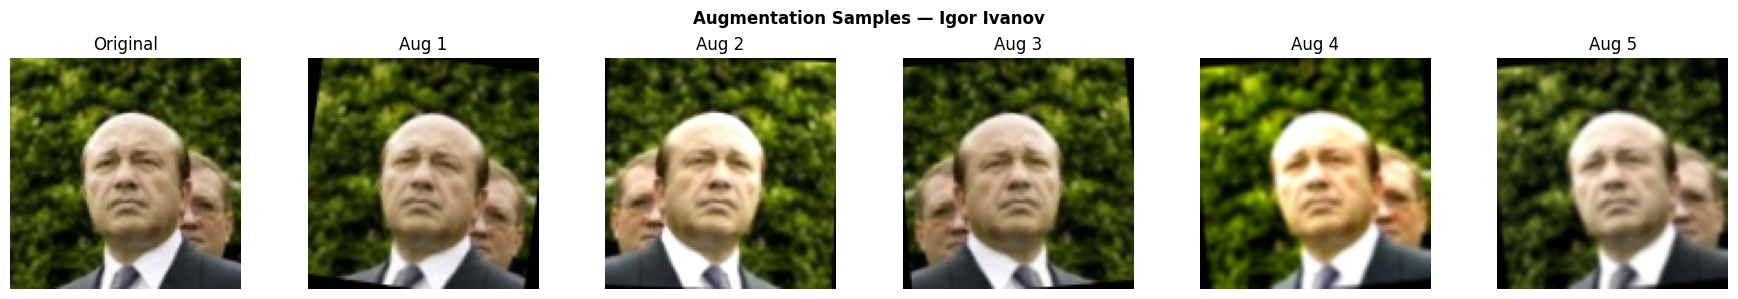

 Plot saved to processed_data/03_augmentation_samples.png


In [30]:
# Visualize augmentation samples
# Show original + 5 augmented versions of one person

sample_person = train_persons[5]
sample_images = train_bank[sample_person]

fig, axes = plt.subplots(1, 6, figsize=(18, 3))
fig.suptitle(f"Augmentation Samples — {sample_person.replace('_', ' ')}",fontsize=12, fontweight='bold')

# Original
orig_path = list((DATA_ROOT / sample_person).glob("*.jpg"))[0]
orig_img  = preprocess_image(orig_path)
axes[0].imshow(orig_img)
axes[0].set_title("Original")
axes[0].axis('off')

# 5 augmented versions
for i in range(1, 6):
    aug = augment_image(orig_img)
    axes[i].imshow(aug)
    axes[i].set_title(f"Aug {i}")
    axes[i].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_augmentation_samples.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Plot saved to processed_data/03_augmentation_samples.png")